In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image                 # βιβλιοθήκη για να "διαβάζουμε" εικόνες (μεταξύ άλλων)
from scipy import signal              # ετεροσυσχέτιση 2D & συνέλιξη
from matplotlib.patches import Rectangle

## Άσκηση - Ανίχνευση Προτύπου σε Εικόνα

Στην άσκηση $\texttt{Ex-SecureComms}$ χρησιμοποιήσαμε την **ετεροσυσχέτιση** για να εντοπίσουμε *πού* εμφανίζεται ένα γνωστό πρότυπο μέσα σε ένα μονοδιάστατο σήμα (ηχογράφηση).

Το ίδιο εργαλείο δουλεύει και σε **δύο διαστάσεις**: μια εικόνα δεν είναι παρά ένα δισδιάστατο σήμα $x[m,n]$, όπου κάθε δείγμα είναι η φωτεινότητα ενός pixel. 

Ας υποθέσουμε ότι έχουμε τη φωτογραφία παρακάτω:

Διαστάσεις εικόνας (H, W): (356, 612)


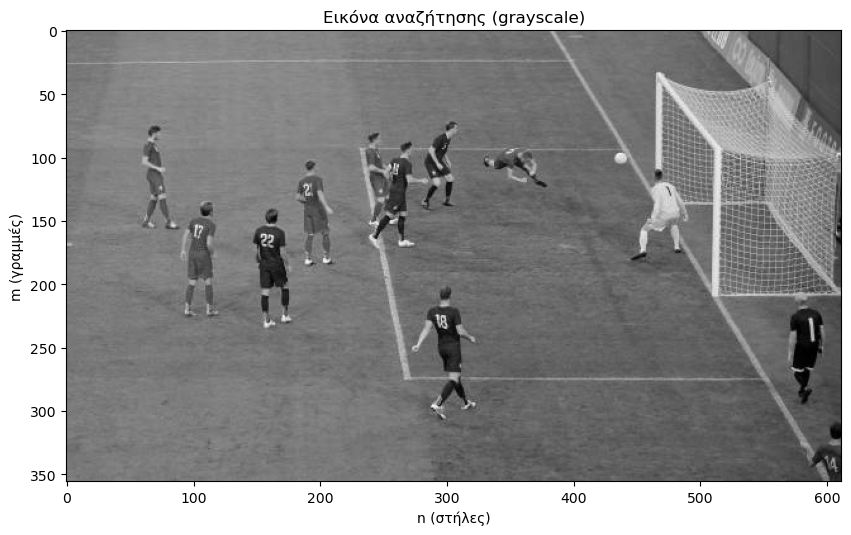

In [2]:
# Διαβάζουμε την εικόνα και τη μετατρέπουμε σε grayscale (1 κανάλι)
img = np.asarray(Image.open('./files/football.jpg').convert('L'), dtype=float)
img = img / 255.0                       # κανονικοποιούμε στο [0,1]

print('Διαστάσεις εικόνας (H, W):', img.shape)

fig = plt.figure(figsize=(10,6))
plt.imshow(img, cmap='gray')
plt.title('Εικόνα αναζήτησης (grayscale)'); plt.xlabel('n (στήλες)'); plt.ylabel('m (γραμμές)')
plt.show()

Αν έχουμε ένα μικρό *πρότυπο* (π.χ. ένα στιγμιότυπο του τερματοφύλακα), μπορούμε να το "σύρουμε" πάνω από ολόκληρη την εικόνα και να μετρήσουμε την ομοιότητα σε κάθε θέση. Η θέση με τη μέγιστη ετεροσυσχέτιση μας δείχνει πού βρίσκεται το πρότυπο, ακριβώς όπως και στη μονοδιάστατη περίπτωση.

Θα δουλέψουμε εξ ολοκλήρου σε **αποχρώσεις του γκρι (grayscale, 1 κανάλι)**, ώστε το σήμα να είναι πραγματικά $x[m,n] \in \mathbb{R}$, όπως ακριβώς και στην 1D περίπτωση (οι έγχρωμες εικόνες είναι 3-καναλικές, ένα κανάλι για κάθε χρώμα από τα Red, Green, Blue (RGB πρότυπο)).

Διαστάσεις προτύπου (h, w): (78, 47)


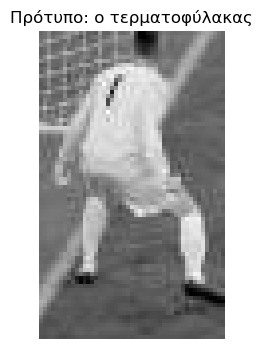

In [3]:
# Εξάγουμε ένα ΣΤΙΓΜΙΟΤΥΠΟ του τερματοφύλακα -> αυτό είναι το πρότυπό μας (pattern/template)
# (γραμμές r0:r1, στήλες c0:c1)
r0, r1 = 112, 190
c0, c1 = 448, 495
pattern = img[r0:r1, c0:c1]             # το πρότυπο, σε grayscale
pattern = np.fliplr(pattern)            # το αναστρέφουμε οριζόντια για να δυσκολέψουμε την αναγνώριση (προαιρετικό)
th, tw = pattern.shape
print('Διαστάσεις προτύπου (h, w):', pattern.shape)

fig = plt.figure(figsize=(3,4))
plt.imshow(pattern, cmap='gray')
plt.title('Πρότυπο: ο τερματοφύλακας'); plt.axis('off')
plt.show()

Θα θέλαμε να βρούμε *πού* μέσα στην εικόνα βρίσκεται το πρότυπο. Όπως και στην 1D περίπτωση, χρησιμοποιούμε την πράξη της **ετεροσυσχέτισης**, τώρα σε δύο διαστάσεις:

$$r_{xy}[k,l] = \sum_{m}\sum_{n} x[m,n]\, y[m+k,\; n+l]$$

όπου $x$ είναι η εικόνα αναζήτησης και $y$ το πρότυπο. Το ζεύγος $(k,l)$ είναι η *καθυστέρηση (lag)* σε γραμμές και στήλες — δηλαδή πόσο έχουμε "ολισθήσει" το πρότυπο πάνω στην εικόνα. Είναι η άμεση γενίκευση της 1D σχέσης

$$r_{xy}[l] = \sum_{n} x[n]\, y[n+l]$$

Η θέση $(k,l)$ όπου η $\phi_{xy}$ γίνεται **μέγιστη** αντιστοιχεί στη θέση όπου το πρότυπο "ταιριάζει" καλύτερα με την εικόνα.

----

Ας δούμε ένα toy example. Έστω μια μικρή "εικόνα" $X$ (5×5) μέσα στην οποία έχουμε "κρύψει" ένα πρότυπο $Y$ (2×2) με υψηλές τιμές. Ας εφαρμόσουμε την 2D ετεροσυσχέτιση και ας δούμε πού εμφανίζεται η κορυφή:

Κορυφή ετεροσυσχέτισης στο (k, l) = (2, 2)


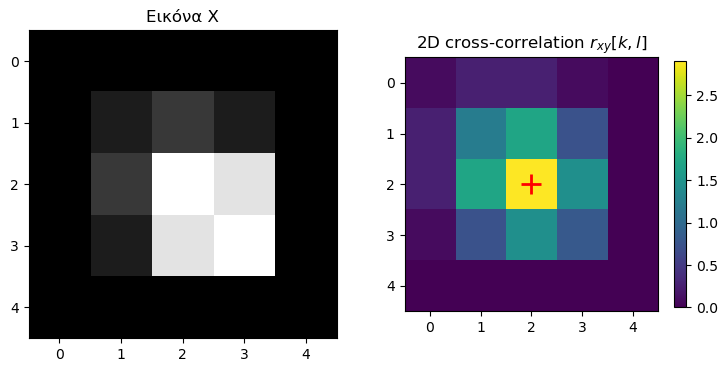

In [13]:
# "Εικόνα" 5x5
X = np.array([[0. , 0. , 0. , 0. , 0. ],
              [0. , 0.1, 0.2, 0.1, 0. ],
              [0. , 0.2, 0.9, 0.8, 0. ],
              [0. , 0.1, 0.8, 0.9, 0. ],
              [0. , 0. , 0. , 0. , 0. ]])

# Πρότυπο 2x2 (η φωτεινή γωνία)
Y = np.array([[0.9, 0.8],
              [0.8, 0.9]])

# 2D Ετεροσυσχέτιση
cc = signal.correlate2d(X, Y, mode='same')

# Θέση της κορυφής (γραμμή, στήλη)
k, l = np.unravel_index(np.argmax(cc), cc.shape)
print('Κορυφή ετεροσυσχέτισης στο (k, l) =', (k, l))

fig, ax = plt.subplots(1, 2, figsize=(9,4))
ax[0].imshow(X, cmap='gray'); ax[0].set_title('Εικόνα X')
im = ax[1].imshow(cc, cmap='viridis'); ax[1].set_title('2D cross-correlation $r_{xy}[k,l]$')
ax[1].plot(l, k, 'r+', markersize=15, markeredgewidth=2)
fig.colorbar(im, ax=ax[1], shrink=0.8)
plt.show()


----

Επιστρέφοντας στο αρχικό πρόβλημα, ο παρακάτω κώδικας θα σας βοηθήσει να εντοπίσετε τον τερματοφύλακα. Χρησιμοποιήστε το *documentation* όπου έχετε αμφιβολία.

## Απάντηση:

**Απλή ετεροσυσχέτιση.** Ας υπολογίσουμε πρώτα την "ωμή" 2D ετεροσυσχέτιση της εικόνας με το πρότυπο, ακριβώς όπως κάναμε στην 1D άσκηση:

Κορυφή (απλή corr) στο κέντρο (γραμμή, στήλη) = (87, 524)


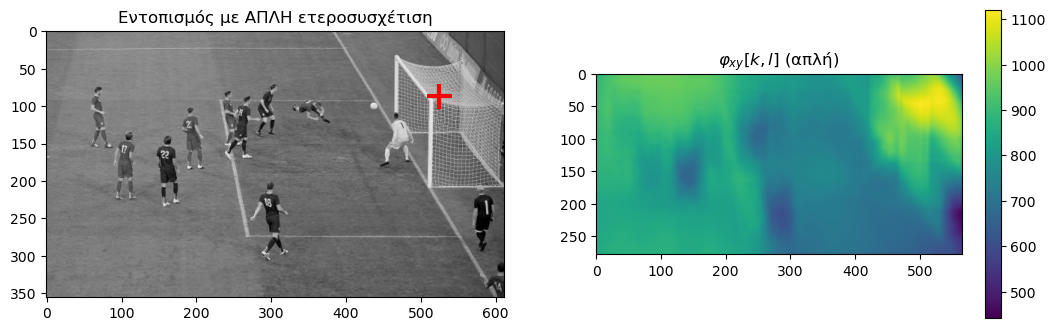

In [15]:
# Απλή (μη κανονικοποιημένη) 2D ετεροσυσχέτιση - mode='valid': το πρότυπο μένει εντός εικόνας
plain = signal.correlate2d(img, pattern, mode='valid')

# Θέση της κορυφής -> πάνω-αριστερή γωνία του προτύπου, μετά το κέντρο του
kr, kc = np.unravel_index(np.argmax(plain), plain.shape)
center_plain = (kr + th // 2, kc + tw // 2)
print('Κορυφή (απλή corr) στο κέντρο (γραμμή, στήλη) =', center_plain)

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].imshow(img, cmap='gray'); ax[0].plot(center_plain[1], center_plain[0], 'r+', ms=18, mew=3)
ax[0].set_title('Εντοπισμός με ΑΠΛΗ ετεροσυσχέτιση')
im = ax[1].imshow(plain, cmap='viridis'); ax[1].set_title('$φ_{xy}[k,l]$ (απλή)')
fig.colorbar(im, ax=ax[1], shrink=0.8)
plt.show()

Παρατηρήστε προσεκτικά: η κορυφή **δεν** έπεσε πάνω στον τερματοφύλακα, αλλά σε μια πολύ **φωτεινή** περιοχή (το λευκό δίχτυ / οι διαφημιστικές πινακίδες). 

Αυτό είναι το κλασικό πρόβλημα της απλής ετεροσυσχέτισης σε εικόνες: η $\sum x\,y$ μεγαλώνει όπου το $x$ έχει απλώς **μεγάλη ενέργεια** (φωτεινά pixels), ανεξάρτητα από το αν το *σχήμα* ταιριάζει. Στην 1D άσκηση αυτό δεν μας ενοχλούσε, γιατί το πρότυπο θορύβου είχε μηδενικό μέσο όρο και σταθερή ενέργεια. Τι κάνουμε λοιπόν;;;

**Η λύση: Κανονικοποιημένη Ετεροσυσχέτιση (Normalized Cross-Correlation, NCC).** Αφαιρούμε τον μέσο όρο από κάθε παράθυρο και από το πρότυπο, και διαιρούμε με τις νόρμες τους:

$$\gamma[k,l] = \frac{\sum_{m,n}\big(x[m+k,n+l]-\bar{x}_{k,l}\big)\big(y[m,n]-\bar{y}\big)}{\sqrt{\sum_{m,n}\big(x[m+k,n+l]-\bar{x}_{k,l}\big)^2}\;\sqrt{\sum_{m,n}\big(y[m,n]-\bar{y}\big)^2}}$$

Έτσι το $\gamma \in [-1,1]$ μετράει **σχήμα**, όχι φωτεινότητα.

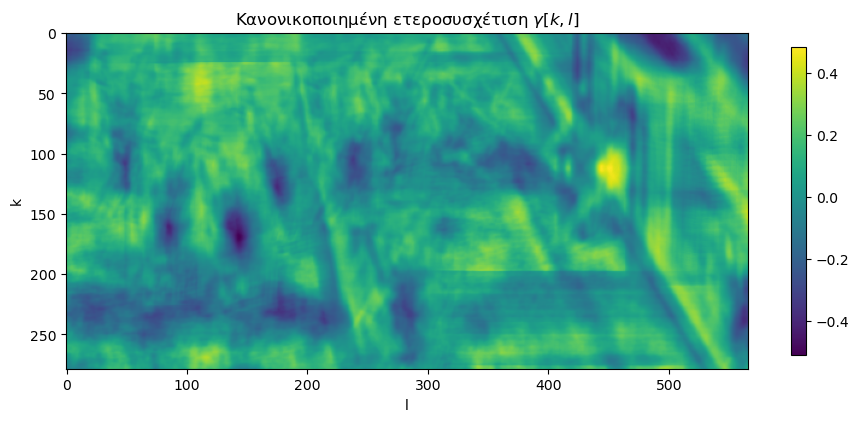

In [16]:
# --- Κανονικοποιημένη Ετεροσυσχέτιση (NCC) μέσω FFT (γρήγορο) ---
t = pattern - pattern.mean()          # πρότυπο μηδενικού μέσου
ones = np.ones_like(pattern)
n = pattern.size

# ετεροσυσχέτιση = συνέλιξη με αναστραμμένο πυρήνα
corr = signal.fftconvolve(img, t[::-1, ::-1], mode='valid')

# τοπικά αθροίσματα του παραθύρου της εικόνας (για μέσο & ενέργεια)
win_sum  = signal.fftconvolve(img, ones, mode='valid')
win_sum2 = signal.fftconvolve(img**2, ones, mode='valid')
local_var = win_sum2 - win_sum**2 / n

denom = np.sqrt(np.clip(local_var, 0, None) * np.sum(t**2))
ncc = np.divide(corr, denom, out=np.zeros_like(corr), where=denom > 1e-9)

fig = plt.figure(figsize=(11,5))
plt.imshow(ncc, cmap='viridis'); plt.colorbar(shrink=0.8)
plt.title('Κανονικοποιημένη ετεροσυσχέτιση $γ[k,l]$'); plt.xlabel('l'); plt.ylabel('k')
plt.show()

In [17]:
# Επιλέγουμε ένα κατώφλι T για να ξεχωρίσουμε την κορυφή απ' το υπόλοιπο σήμα (παίξτε με αυτήν την τιμή!)
T = 0.4

# Θέση της μέγιστης συσχέτισης
kr, kc = np.unravel_index(np.argmax(ncc), ncc.shape)
peak_val = ncc[kr, kc]

# Πόσες θέσεις ξεπερνούν το κατώφλι; (αναμένουμε ουσιαστικά μία -> έναν τερματοφύλακα)
detections = np.argwhere(ncc >= T)
print(f'Τιμή κορυφής NCC = {peak_val:.3f}  (κατώφλι T = {T})')
print(f'Θέσεις πάνω απ\'το κατώφλι = {len(detections)}')
if len(detections) > 1:
    print('Προσοχή: βρέθηκαν περισσότερες από μία κορυφές πάνω απ\'το κατώφλι!')
elif len(detections) == 0:
    print('Προσοχή: δεν βρέθηκαν κορυφές πάνω απ\'το κατώφλι!')
elif len(detections) == 1:
    print(f'Κορυφή στο (k, l) = {(kr, kc)}  ->  κέντρο προτύπου (γραμμή, στήλη) = {(kr + th//2, kc + tw//2)}')
else:
    print('Απροσδόκητο αποτέλεσμα στον έλεγχο κορυφών!')

Τιμή κορυφής NCC = 0.484  (κατώφλι T = 0.4)
Θέσεις πάνω απ'το κατώφλι = 264
Προσοχή: βρέθηκαν περισσότερες από μία κορυφές πάνω απ'το κατώφλι!


Προσοχή: βρέθηκαν περισσότερες από μία κορυφές πάνω απ'το κατώφλι! Θα σχεδιάσουμε μόνο την κορυφή με τη μέγιστη τιμή.


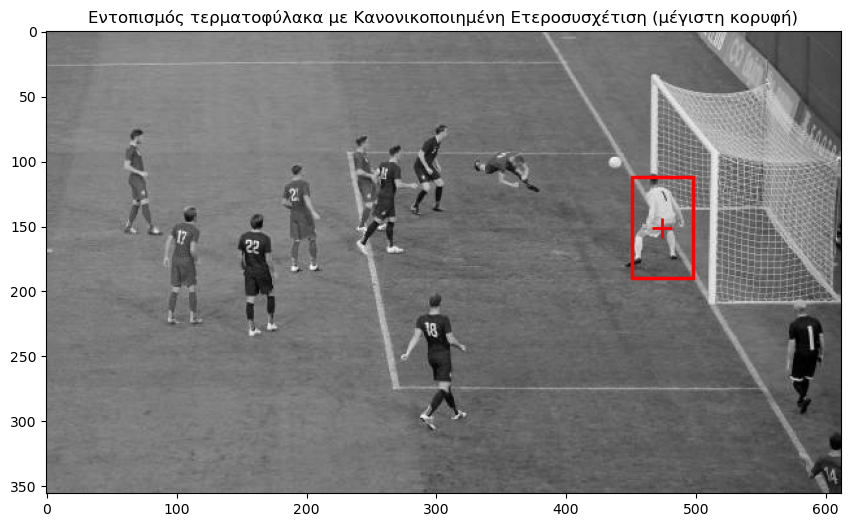

In [8]:
if len(detections) == 1:
    print(f'Κορυφή στο (k, l) = {(kr, kc)}  ->  κέντρο προτύπου (γραμμή, στήλη) = {(kr + th//2, kc + tw//2)}')
    # Σχεδιάζουμε το πλαίσιο (bounding box) στη θέση που εντοπίσαμε
    top_left = (kc, kr)                    # (x=στήλη, y=γραμμή) για το Rectangle

    fig, ax = plt.subplots(figsize=(11,6))
    ax.imshow(img, cmap='gray')
    rect = Rectangle(top_left, tw, th, linewidth=2.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.plot(kc + tw//2, kr + th//2, 'r+', ms=15, mew=2)
    ax.set_title('Εντοπισμός τερματοφύλακα με Κανονικοποιημένη Ετεροσυσχέτιση')
    plt.show()
elif len(detections) > 1:
    print('Προσοχή: βρέθηκαν περισσότερες από μία κορυφές πάνω απ\'το κατώφλι! Θα σχεδιάσουμε μόνο την κορυφή με τη μέγιστη τιμή.')
    # Σχεδιάζουμε το πλαίσιο (bounding box) στη θέση που εντοπίσαμε τη μέγιστη κορυφή
    top_left = (kc, kr)                    # (x=στήλη, y=γραμμή) για το Rectangle
    fig, ax = plt.subplots(figsize=(11,6))
    ax.imshow(img, cmap='gray')
    rect = Rectangle(top_left, tw, th, linewidth=2.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.plot(kc + tw//2, kr + th//2, 'r+', ms=15, mew=2)
    ax.set_title('Εντοπισμός τερματοφύλακα με Κανονικοποιημένη Ετεροσυσχέτιση (μέγιστη κορυφή)')
    plt.show()
else:
    print('Προσοχή: δεν βρέθηκαν κορυφές πάνω απ\'το κατώφλι! Δεν σχεδιάζεται bounding box.')

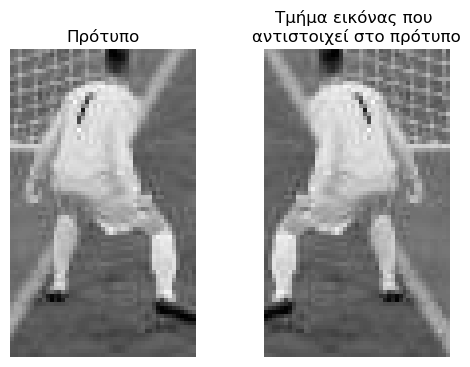

In [9]:
# Για δείτε! Πρότυπο vs. περιοχή που εντοπίστηκε
found = img[kr:kr+th, kc:kc+tw]

fig, ax = plt.subplots(1, 2, figsize=(6,4))
ax[0].imshow(pattern, cmap='gray'); ax[0].set_title('Πρότυπο'); ax[0].axis('off')
ax[1].imshow(found,   cmap='gray'); ax[1].set_title('Τμήμα εικόνας που \nαντιστοιχεί στο πρότυπο'); ax[1].axis('off')
plt.show()

---
---